# FLMVDM Noise Schedule Explorer

Use this notebook to sample `tau` values and inspect how each FLMVDM schedule maps them to `gamma`, `SNR`, `alpha`, and VLB/SNR-prime weights. The time convention is the FLM convention: `tau=0` is noise and `tau=1` is data.

In [ ]:
# Main controls
SCHEDULE_TYPE = "argmax_uncertainty"  # linear, learned_vdm, argmax_uncertainty, snr_power
LATENT_TYPE = "linear_interp"           # vp or linear_interp
IMPORTANCE_SAMPLING = True

N_SAMPLES = 10_000
GRID_POINTS = 1_000
SEED = 0

# Use a clipped interval for schedules with singular endpoints, especially snr_power.
T_MIN = 0
T_MAX = 1.0

SCHEDULE_PARAMS = {
    "gamma_min": -3,
    "gamma_max": 13,
    "C": 17.276323318481445,
    "p": 0.43169814348220825,
    "eps": 1e-6,
    "hidden_size": 128,
    "vocab_size": 30_522, #50_257,
    # Lower this for fast interactive argmax_uncertainty exploration.
    "n_points": 2_000,
    "n_gh": 64,
}

In [83]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import noise_schedules

torch.set_default_dtype(torch.float64)
plt.style.use("seaborn-v0_8-whitegrid")

In [84]:
def make_schedule(schedule_type=SCHEDULE_TYPE, params=SCHEDULE_PARAMS):
    return noise_schedules.build_noise_schedule(
        schedule_type,
        vocab_size=params["vocab_size"],
        gamma_min=params["gamma_min"],
        gamma_max=params["gamma_max"],
        C=params["C"],
        p=params["p"],
        eps=params["eps"],
        hidden_size=params["hidden_size"],
        n_points=params["n_points"],
        n_gh=params["n_gh"],
    ).eval()


def alpha_sigma_from_gamma(gamma, latent_type=LATENT_TYPE):
    if latent_type == "vp":
        alpha = torch.sigmoid(-gamma).sqrt()
        sigma = torch.sigmoid(gamma).sqrt()
    elif latent_type in {"linear", "linear_interp"}:
        alpha = torch.sigmoid(-0.5 * gamma)
        sigma = torch.sigmoid(0.5 * gamma)
    else:
        raise ValueError(f"Unknown latent_type: {latent_type}")
    return alpha, sigma


def uniform_tau(n=N_SAMPLES, t_min=T_MIN, t_max=T_MAX, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return t_min + (t_max - t_min) * torch.rand(n, generator=generator)


def evaluate(schedule, tau, latent_type=LATENT_TYPE):
    gamma, snr_prime = schedule(tau)
    snr = torch.exp(-gamma)
    alpha, sigma = alpha_sigma_from_gamma(gamma, latent_type=latent_type)
    return {
        "tau": tau.detach(),
        "gamma": gamma.detach(),
        "snr": snr.detach(),
        "alpha": alpha.detach(),
        "sigma": sigma.detach(),
        "snr_prime": snr_prime.detach(),
        "vlb_weight": snr_prime.detach(),
    }


def evaluate_importance(schedule, n=N_SAMPLES, t_min=T_MIN, t_max=T_MAX, seed=SEED,
                        latent_type=LATENT_TYPE):
    generator = torch.Generator().manual_seed(seed)
    unit = torch.rand(n, generator=generator)
    tau, gamma, vlb_weight = schedule.importance_sample(unit, t_min=t_min, t_max=t_max)
    _, snr_prime = schedule(tau)
    snr = torch.exp(-gamma)
    alpha, sigma = alpha_sigma_from_gamma(gamma, latent_type=latent_type)
    return {
        "unit": unit.detach(),
        "tau": tau.detach(),
        "gamma": gamma.detach(),
        "snr": snr.detach(),
        "alpha": alpha.detach(),
        "sigma": sigma.detach(),
        "snr_prime": snr_prime.detach(),
        "vlb_weight": vlb_weight.detach(),
    }


def to_numpy(values):
    return values.detach().cpu().numpy()


def summarize(values, names):
    rows = []
    for name in names:
        arr = to_numpy(values[name])
        rows.append((name, arr.mean(), arr.std(), arr.min(), np.median(arr), arr.max()))
    print(f"{'value':<12} {'mean':>13} {'std':>13} {'min':>13} {'median':>13} {'max':>13}")
    for row in rows:
        print(f"{row[0]:<12} {row[1]:13.6g} {row[2]:13.6g} {row[3]:13.6g} {row[4]:13.6g} {row[5]:13.6g}")

## Inspect One Schedule

This section samples taus uniformly from `[T_MIN, T_MAX]` unless `IMPORTANCE_SAMPLING=True`, in which case it samples uniformly in SNR space and reports the effective tau.

In [85]:
schedule = make_schedule(SCHEDULE_TYPE)

if IMPORTANCE_SAMPLING:
    sampled = evaluate_importance(schedule)
    value_names = ["tau", "gamma", "snr", "alpha", "sigma", "snr_prime", "vlb_weight"]
    sample_mode = "importance sampling"
else:
    tau_samples = uniform_tau()
    sampled = evaluate(schedule, tau_samples)
    value_names = ["tau", "gamma", "snr", "alpha", "sigma", "snr_prime", "vlb_weight"]
    sample_mode = "uniform tau sampling"

print(f"{type(schedule).__name__} ({sample_mode}, latent_type={LATENT_TYPE}, t=[{T_MIN}, {T_MAX}])")
summarize(sampled, value_names)

ArgmaxUncertaintySchedule (importance sampling, latent_type=linear_interp, t=[0, 1.0])
value                 mean           std           min        median           max
tau              0.0854667     0.0827394   3.52226e-06     0.0573097      0.273522
gamma             -1.50904      0.999203      -2.49986       -1.8172       7.38756
snr                6.13157       3.51806   0.000618901       6.15462       12.1808
alpha             0.674588      0.111191     0.0242738      0.712714      0.777288
sigma             0.325412      0.111191      0.222712      0.287286      0.975726
snr_prime          146.902       258.954       22.1868       43.2124       1548.76
vlb_weight         12.1825   3.55271e-15       12.1825       12.1825       12.1825


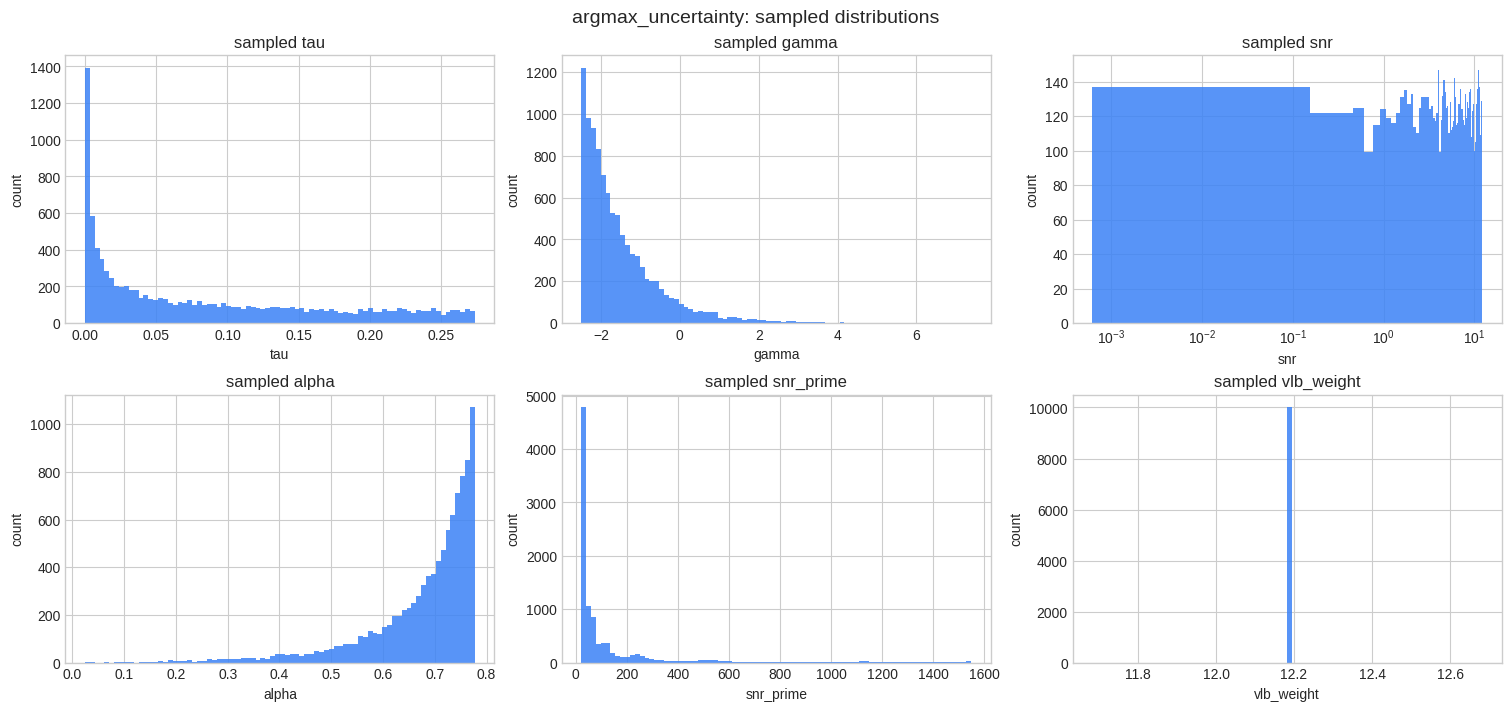

In [86]:
hist_names = [name for name in value_names if name != "sigma"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
axes = axes.ravel()

for ax, name in zip(axes, hist_names):
    arr = to_numpy(sampled[name])
    ax.hist(arr, bins=80, color="#3b82f6", alpha=0.85)
    ax.set_title(f"sampled {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("count")  
    if name in {"snr", "snr_prime", "vlb_weight"} and np.nanmax(arr) / max(np.nanmin(arr[arr > 0]), 1e-300) > 100:
        ax.set_xscale("log")

for ax in axes[len(hist_names):]:
    ax.axis("off")

fig.suptitle(f"{SCHEDULE_TYPE}: sampled distributions", fontsize=14)
plt.show()

## Tau Curves

These plots show the deterministic schedule map from tau to gamma, SNR, alpha, and SNR-prime weight.

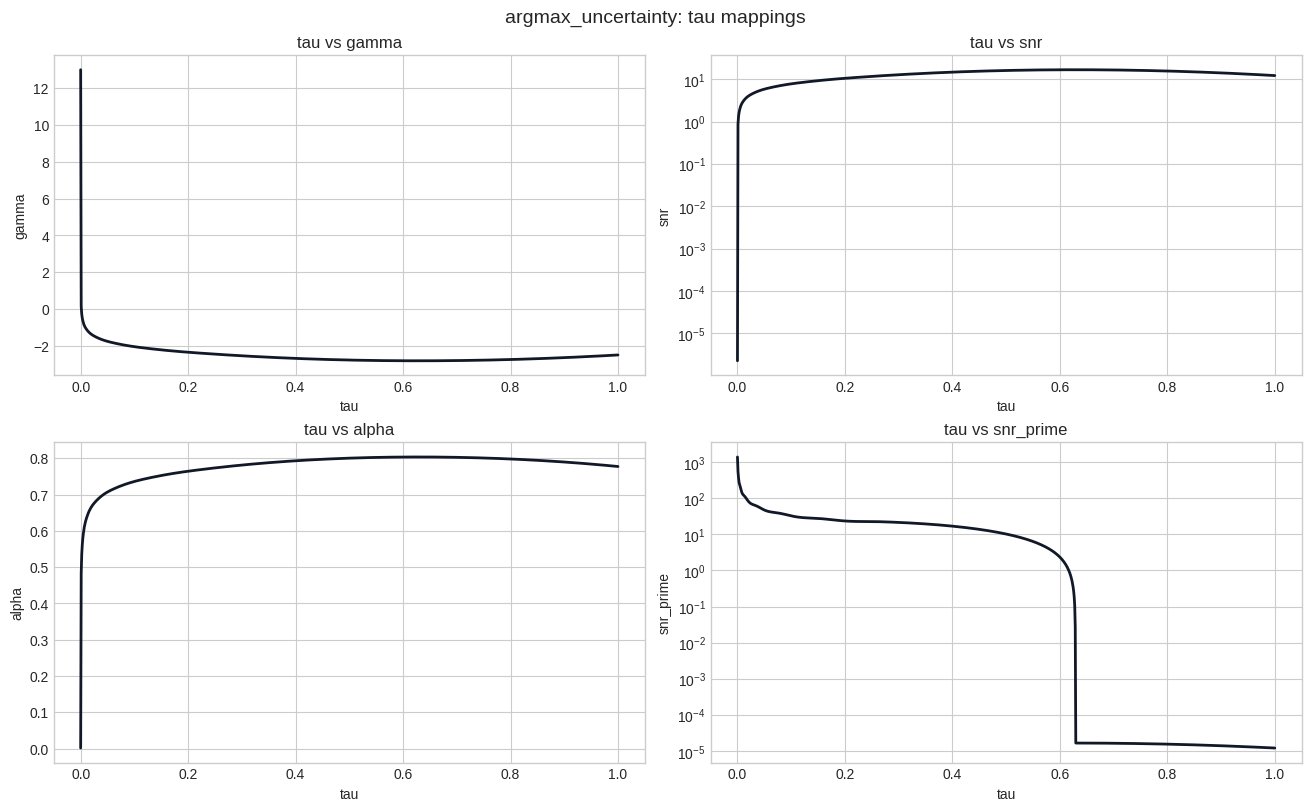

In [87]:
tau_grid = torch.linspace(T_MIN, T_MAX, GRID_POINTS)
curves = evaluate(schedule, tau_grid)

curve_specs = [
    ("gamma", "linear"),
    ("snr", "log"),
    ("alpha", "linear"),
    ("snr_prime", "log"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
axes = axes.ravel()
x = to_numpy(curves["tau"])

for ax, (name, scale) in zip(axes, curve_specs):
    y = to_numpy(curves[name])
    ax.plot(x, y, lw=2.0, color="#111827")
    ax.set_title(f"tau vs {name}")
    ax.set_xlabel("tau")
    ax.set_ylabel(name)
    if scale == "log":
        ax.set_yscale("log")

fig.suptitle(f"{SCHEDULE_TYPE}: tau mappings", fontsize=14)
plt.show()

## Compare All Schedules

This builds every schedule with the same config and overlays their tau curves. `argmax_uncertainty` is the most expensive to build; reduce `n_points` above if this cell is slow.

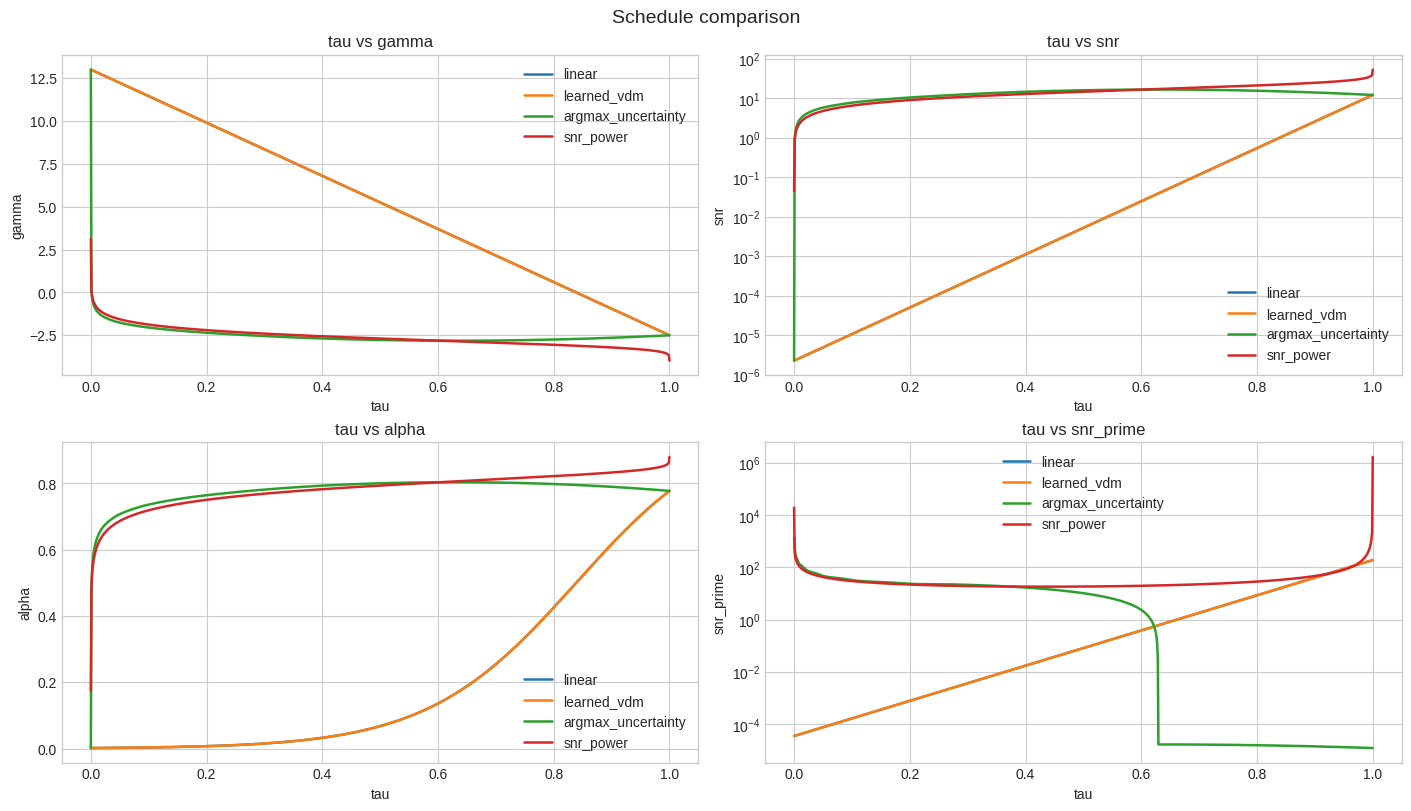

In [88]:
schedule_names = ["linear", "learned_vdm", "argmax_uncertainty", "snr_power"]
schedules = {name: make_schedule(name) for name in schedule_names}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

for name, sched in schedules.items():
    vals = evaluate(sched, tau_grid)
    for ax, (metric, scale) in zip(axes, curve_specs):
        ax.plot(to_numpy(vals["tau"]), to_numpy(vals[metric]), label=name, lw=1.8)
        ax.set_title(f"tau vs {metric}")
        ax.set_xlabel("tau")
        ax.set_ylabel(metric)
        if scale == "log":
            ax.set_yscale("log")

for ax in axes:
    ax.legend()

fig.suptitle("Schedule comparison", fontsize=14)
plt.show()

## Argmax Correctness at gamma_min

This diagnostic verifies whether the Gaussian latent at `gamma_min` preserves the original token under an argmax decoder. It compares the exact Gaussian order-statistic probability against a fast Monte Carlo estimate that samples only the target-coordinate noise and the maximum non-target noise coordinate.


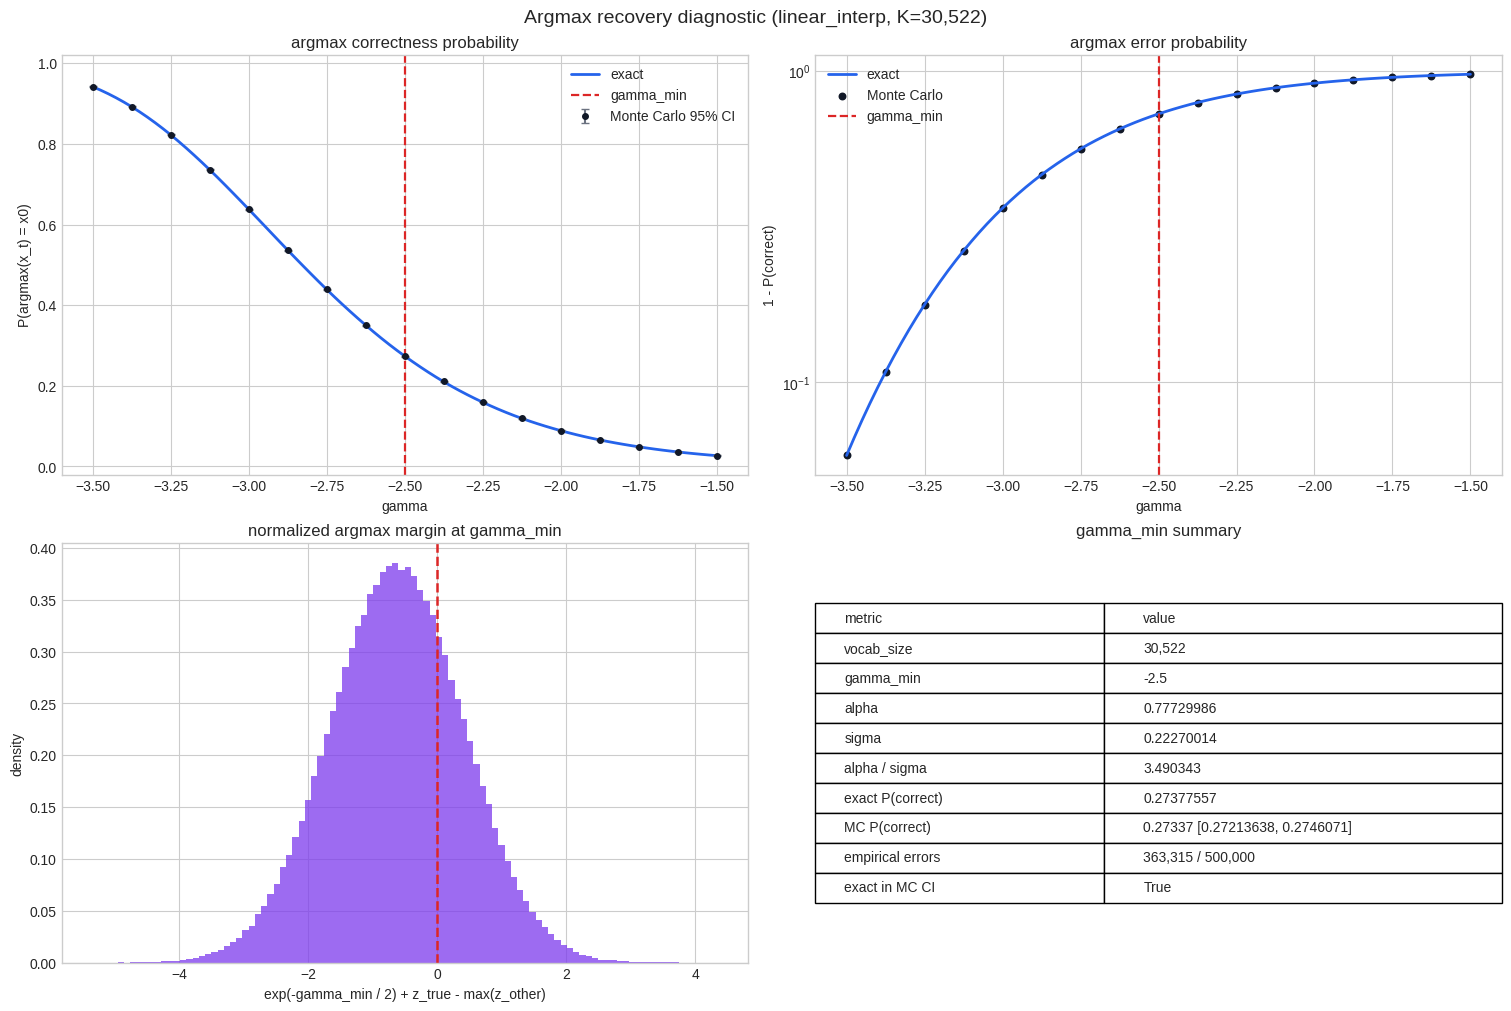

In [89]:
from numpy.polynomial.hermite import hermgauss
from scipy.special import log_ndtr, ndtr, ndtri

ARGMAX_MC_TRIALS = 500_000
ARGMAX_GAMMA_HALF_WIDTH = 1.0
ARGMAX_GAMMA_POINTS = 81
TARGET_CORRECT_PROB = None


def exact_argmax_correctness(gamma_values, vocab_size, n_gh=96):
    gamma_values = np.asarray(gamma_values, dtype=np.float64)
    vocab_size = int(vocab_size)
    if vocab_size < 2:
        raise ValueError("vocab_size must be at least 2")

    margins = np.exp(-0.5 * gamma_values)
    nodes, weights = hermgauss(int(n_gh))
    weights = weights / np.sqrt(np.pi)
    z_nodes = np.sqrt(2.0) * nodes
    log_terms = (vocab_size - 1) * log_ndtr(z_nodes[None, :] + margins[:, None])
    return np.sum(weights[None, :] * np.exp(log_terms), axis=1)


def wilson_interval(successes, trials, confidence_z=1.959963984540054):
    successes = np.asarray(successes, dtype=np.float64)
    trials = float(trials)
    phat = successes / trials
    denom = 1.0 + confidence_z ** 2 / trials
    center = (phat + confidence_z ** 2 / (2.0 * trials)) / denom
    half_width = confidence_z * np.sqrt(
        (phat * (1.0 - phat) + confidence_z ** 2 / (4.0 * trials)) / trials
    ) / denom
    low = np.clip(center - half_width, 0.0, 1.0)
    high = np.clip(center + half_width, 0.0, 1.0)
    return low, high


vocab_size = int(SCHEDULE_PARAMS["vocab_size"])
gamma_min_value = float(SCHEDULE_PARAMS["gamma_min"])
gamma_grid = np.linspace(
    gamma_min_value - ARGMAX_GAMMA_HALF_WIDTH,
    gamma_min_value + ARGMAX_GAMMA_HALF_WIDTH,
    ARGMAX_GAMMA_POINTS,
)
exact_correct = exact_argmax_correctness(gamma_grid, vocab_size)
exact_at_gamma_min = exact_argmax_correctness([gamma_min_value], vocab_size)[0]

assert np.all(np.diff(exact_correct) <= 1e-10), "P(correct) should decrease as gamma increases"
k2_gamma = np.array([gamma_min_value], dtype=np.float64)
k2_margin = np.exp(-0.5 * k2_gamma[0])
k2_exact = exact_argmax_correctness(k2_gamma, vocab_size=2)[0]
k2_closed_form = ndtr(k2_margin / np.sqrt(2.0))
assert np.allclose(k2_exact, k2_closed_form, atol=5e-5), "K=2 sanity check failed"

rng = np.random.default_rng(SEED)
u = np.clip(rng.random(ARGMAX_MC_TRIALS), np.finfo(np.float64).tiny, 1.0 - np.finfo(np.float64).eps)
z_true = rng.standard_normal(ARGMAX_MC_TRIALS)
# Stable equivalent of ndtri(u ** (1.0 / (vocab_size - 1))).
max_other = -ndtri(-np.expm1(np.log(u) / (vocab_size - 1)))

mc_indices = np.unique(np.linspace(0, ARGMAX_GAMMA_POINTS - 1, min(17, ARGMAX_GAMMA_POINTS)).round().astype(int))
mc_gamma = gamma_grid[mc_indices]
mc_margins = np.exp(-0.5 * mc_gamma)
mc_successes = np.array([np.count_nonzero(margin + z_true > max_other) for margin in mc_margins])
mc_correct = mc_successes / ARGMAX_MC_TRIALS
mc_ci_low, mc_ci_high = wilson_interval(mc_successes, ARGMAX_MC_TRIALS)
mc_yerr = np.maximum(0.0, np.vstack([mc_correct - mc_ci_low, mc_ci_high - mc_correct]))

gamma_min_margin = np.exp(-0.5 * gamma_min_value)
gamma_min_normalized_margin = gamma_min_margin + z_true - max_other
gamma_min_successes = np.count_nonzero(gamma_min_normalized_margin > 0.0)
gamma_min_mc_correct = gamma_min_successes / ARGMAX_MC_TRIALS
gamma_min_ci_low, gamma_min_ci_high = wilson_interval(gamma_min_successes, ARGMAX_MC_TRIALS)
ci_contains_exact = gamma_min_ci_low <= exact_at_gamma_min <= gamma_min_ci_high

gamma_min_tensor = torch.tensor(gamma_min_value, dtype=torch.get_default_dtype())
alpha_min, sigma_min = alpha_sigma_from_gamma(gamma_min_tensor)
alpha_min = float(alpha_min.detach().cpu())
sigma_min = float(sigma_min.detach().cpu())

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
prob_ax, err_ax, margin_ax, table_ax = axes.ravel()

prob_ax.plot(gamma_grid, exact_correct, color="#2563eb", lw=2.0, label="exact")
prob_ax.errorbar(
    mc_gamma,
    mc_correct,
    yerr=mc_yerr,
    fmt="o",
    ms=4,
    color="#111827",
    ecolor="#6b7280",
    capsize=3,
    label="Monte Carlo 95% CI",
)
prob_ax.axvline(gamma_min_value, color="#dc2626", ls="--", lw=1.6, label="gamma_min")
if TARGET_CORRECT_PROB is not None:
    prob_ax.axhline(float(TARGET_CORRECT_PROB), color="#059669", ls=":", lw=1.8, label="target")
prob_ax.set_title("argmax correctness probability")
prob_ax.set_xlabel("gamma")
prob_ax.set_ylabel("P(argmax(x_t) = x0)")
prob_ax.set_ylim(-0.02, 1.02)
prob_ax.legend()

error_floor = max(1e-12, 0.5 / ARGMAX_MC_TRIALS)
err_ax.plot(gamma_grid, np.clip(1.0 - exact_correct, error_floor, None), color="#2563eb", lw=2.0, label="exact")
err_ax.scatter(mc_gamma, np.clip(1.0 - mc_correct, error_floor, None), color="#111827", s=22, label="Monte Carlo")
err_ax.axvline(gamma_min_value, color="#dc2626", ls="--", lw=1.6, label="gamma_min")
err_ax.set_title("argmax error probability")
err_ax.set_xlabel("gamma")
err_ax.set_ylabel("1 - P(correct)")
err_ax.set_yscale("log")
err_ax.legend()

margin_ax.hist(gamma_min_normalized_margin, bins=100, density=True, color="#7c3aed", alpha=0.75)
margin_ax.axvline(0.0, color="#dc2626", ls="--", lw=1.8)
margin_ax.set_title("normalized argmax margin at gamma_min")
margin_ax.set_xlabel("exp(-gamma_min / 2) + z_true - max(z_other)")
margin_ax.set_ylabel("density")

summary_rows = [
    ("vocab_size", f"{vocab_size:,}"),
    ("gamma_min", f"{gamma_min_value:.10g}"),
    ("alpha", f"{alpha_min:.8g}"),
    ("sigma", f"{sigma_min:.8g}"),
    ("alpha / sigma", f"{gamma_min_margin:.8g}"),
    ("exact P(correct)", f"{exact_at_gamma_min:.8g}"),
    ("MC P(correct)", f"{gamma_min_mc_correct:.8g} [{gamma_min_ci_low:.8g}, {gamma_min_ci_high:.8g}]"),
    ("empirical errors", f"{ARGMAX_MC_TRIALS - gamma_min_successes:,} / {ARGMAX_MC_TRIALS:,}"),
    ("exact in MC CI", str(bool(ci_contains_exact))),
]
table_ax.axis("off")
summary_table = table_ax.table(
    cellText=summary_rows,
    colLabels=["metric", "value"],
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.42, 0.58],
)
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(10)
summary_table.scale(1.0, 1.5)
table_ax.set_title("gamma_min summary")

fig.suptitle(f"Argmax recovery diagnostic ({LATENT_TYPE}, K={vocab_size:,})", fontsize=14)
plt.show()


## Importance Sampling View

Compare the current schedule under uniform `tau` sampling and importance sampling. This keeps the schedule fixed, shows how the induced `tau`, `gamma`, and `snr` distributions shift, and reports the corresponding summary statistics.

ArgmaxUncertaintySchedule comparison (latent_type=linear_interp, t=[0, 1.0])

uniform tau sampling
value                 mean           std           min        median           max
tau                0.50331       0.28878    5.0617e-05      0.505202      0.999857
gamma             -2.53413      0.382494      -2.81717      -2.66554       2.91308
snr                13.3071        3.4826     0.0543082       14.3757       16.7294
alpha             0.778609     0.0371547      0.188997      0.791298      0.803542
sigma             0.221391     0.0371547      0.196458      0.208702      0.811003
snr_prime          16.6818       41.2069   1.21854e-05       9.82476       1534.23
vlb_weight         16.6818       41.2069   1.21854e-05       9.82476       1534.23

importance sampling
value                 mean           std           min        median           max
tau              0.0854667     0.0827394   3.52226e-06     0.0573097      0.273522
gamma             -1.50904      0.999203      -2.4

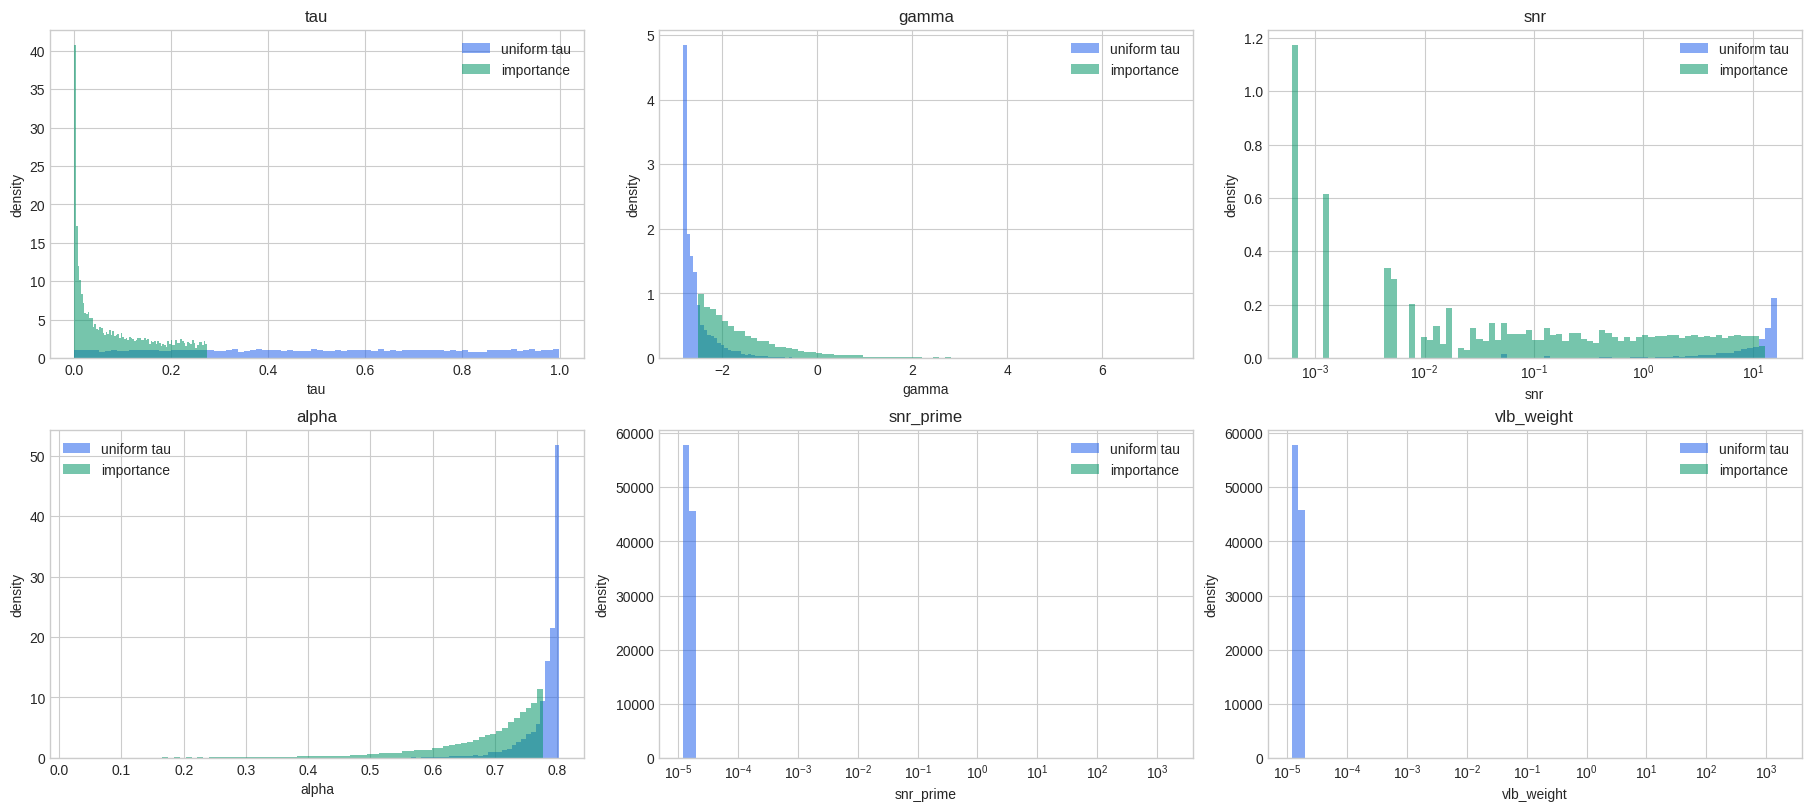

In [90]:
comparison_schedule = make_schedule(SCHEDULE_TYPE)
compare_uniform = evaluate(comparison_schedule, uniform_tau())
compare_importance = evaluate_importance(comparison_schedule)

print(f"{type(comparison_schedule).__name__} comparison (latent_type={LATENT_TYPE}, t=[{T_MIN}, {T_MAX}])")
print()
print("uniform tau sampling")
summarize(compare_uniform, ["tau", "gamma", "snr", "alpha", "sigma", "snr_prime", "vlb_weight"])
print()
print("importance sampling")
summarize(compare_importance, ["tau", "gamma", "snr", "alpha", "sigma", "snr_prime", "vlb_weight"])

fig, axes = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
axes = axes.ravel()
metrics = ["tau", "gamma", "snr", "alpha", "snr_prime", "vlb_weight"]
colors = {
    "uniform": "#2563eb",
    "importance": "#059669",
}

for ax, metric in zip(axes, metrics):
    uniform_arr = to_numpy(compare_uniform[metric])
    importance_arr = to_numpy(compare_importance[metric])
    use_log_x = metric in {"snr", "snr_prime", "vlb_weight"}
    if use_log_x:
        combined = np.concatenate([uniform_arr, importance_arr])
        positive = combined[np.isfinite(combined) & (combined > 0)]
    if use_log_x and positive.size > 0 and positive.max() > positive.min():
        bins = np.geomspace(max(positive.min(), 1e-12), positive.max(), 80)
    else:
        bins = 80
        use_log_x = False
    ax.hist(
        uniform_arr,
        bins=bins,
        density=True,
        alpha=0.55,
        color=colors["uniform"],
        label="uniform tau",
    )
    ax.hist(
        importance_arr,
        bins=bins,
        density=True,
        alpha=0.55,
        color=colors["importance"],
        label="importance",
    )
    ax.set_title(metric)
    ax.set_xlabel(metric)
    ax.set_ylabel("density")
    if use_log_x:
        ax.set_xscale("log")
    ax.legend()

for ax in axes[len(metrics):]:
    ax.set_visible(False)

plt.show()